# Energy Demand Forecast: Modeling and Benchmark

This notebook covers Checkpoint 3. We load the `features_dataset.parquet` engineered previously, perform an 80/20 chronological test split, and benchmark models forecasting load $t+24$ hours ahead.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Replace <USERNAME> with your GitHub username if necessary
!git clone https://github.com/lburdman/energy-demand-forecast.git
%cd energy-demand-forecast
!pip install xgboost scikit-learn statsmodels

Cloning into 'energy-demand-forecast'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 53 (delta 23), reused 42 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 1.34 MiB | 4.32 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/energy-demand-forecast/energy-demand-forecast


In [16]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")

if os.path.abspath("src") not in sys.path:
    sys.path.append(os.path.abspath("."))

from src import data_loader, models

## 1. Load Dataset & Train-Test Split

Load our processed feature set. Since we are doing time series forecasting natively, we must utilize a strict 80-20 forward-flowing chronological time split avoiding cross-validation test leakage structurally.

In [17]:
DRIVE_ROOT = "/content/drive/MyDrive/energy-demand-forecast"
paths = data_loader.get_drive_paths(DRIVE_ROOT)

dataset_path = os.path.join(paths['processed_data'], 'features_dataset.parquet')
df = pd.read_parquet(dataset_path)

# Time-Based Split: 80% Train, 20% Test sequentially using wrapper maintaining strict leakage bounds
X_train, X_test, y_train, y_test = models.train_test_split_time(df, split_ratio=0.8)

print(f"Training set shape safely sized to: {X_train.shape}")
print(f"Testing bound sizes: {X_test.shape}")


Training set shape safely sized to: (40166, 14)
Testing bound sizes: (10042, 14)


## 2. Baseline Model (Naive 24hr Target)

In [18]:
y_pred_naive = models.predict_naive_lag24(X_test)
metrics_naive = models.calculate_metrics(y_test, y_pred_naive)
print(f"Naive Benchmark Metrics: {metrics_naive}")


Naive Benchmark Metrics: {'RMSE': np.float64(8993.080031313611), 'MAE': 6792.20902210715, 'MAPE': 0.1293431828017051}


## 3. Ridge Regression (Fast baseline)
Utilizes standard L2 regularization to rapidly evaluate standardized weights without the overhead of SARIMA.

In [19]:
print("Training Ridge pipeline...")
ridge_model = models.train_ridge(X_train, y_train, alpha=1.0)
y_pred_ridge = pd.Series(ridge_model.predict(X_test), index=y_test.index)
metrics_ridge = models.calculate_metrics(y_test, y_pred_ridge)
print(f"Ridge Predictive Metrics: {metrics_ridge}")


Training Ridge pipeline...
Ridge Predictive Metrics: {'RMSE': np.float64(5016.674793660028), 'MAE': 3948.1607998866107, 'MAPE': 0.07552026032602471}


## 4. Random Forest Regressor
Integrates structural dependencies spanning multiple engineered temporal factors mapping directly alongside $t+24$ structures cleanly via deep trees mathematically aggregating recursive relationships.

In [20]:
print("Training internal RF ensemble...")
rf_model = models.train_random_forest(X_train, y_train)
y_pred_rf = pd.Series(rf_model.predict(X_test), index=y_test.index)
metrics_rf = models.calculate_metrics(y_test, y_pred_rf)
print(f"RandomForest Core Metrics: {metrics_rf}")


Training internal RF ensemble...
RandomForest Core Metrics: {'RMSE': np.float64(2258.2168216965033), 'MAE': 1475.353106989259, 'MAPE': 0.028750519309542304}


## 5. XGBoost Regressor
Utilizes standard stochastic tree groupings mapped explicitly upon feature relationships safely evaluating the core load prediction boundaries without mathematical leakage seamlessly via highly tuned depth properties.

In [21]:
print("Executing XGB stochastic framework...")
xgb_model = models.train_xgboost(X_train, y_train)
y_pred_xgb = pd.Series(xgb_model.predict(X_test), index=y_test.index)
metrics_xgb = models.calculate_metrics(y_test, y_pred_xgb)
print(f"XGBoost System Metrics: {metrics_xgb}")


Executing XGB stochastic framework...
XGBoost System Metrics: {'RMSE': np.float64(2238.995473788853), 'MAE': 1482.1566028150519, 'MAPE': 0.029087002010692403}


## 6. Model Comparison & Metrics Export
We evaluate structurally and generate DataFrame tables securely returning cleanly formatted artifacts directly back to user scopes sequentially mapping results universally towards Google Drive paths globally.

In [22]:
results_metrics = {
    # 'SARIMA': metrics_sarima, # Removed
    'Naive': metrics_naive,
    'Ridge': metrics_ridge,
    'RandomForest': metrics_rf,
    'XGBoost': metrics_xgb
}

results_df = pd.DataFrame(results_metrics).T.reset_index()
results_df.rename(columns={'index': 'Model'}, inplace=True)

print('Model Comparison Results:')
display(results_df)

metrics_path = os.path.join(paths['figures'].replace('figures', ''), 'model_metrics.csv')
results_df.to_csv(metrics_path, index=False)
print(f'Saved metrics securely to {metrics_path}')


Model Comparison Results:


,Model,RMSE,MAE,MAPE
0,Naive,8993.080031,6792.209022,0.129343
1,Ridge,5016.674794,3948.160800,0.075520
2,RandomForest,2258.216822,1475.353107,0.028751
3,XGBoost,2238.995474,1482.156603,0.029087


Saved metrics securely to /content/drive/MyDrive/energy-demand-forecast/results/model_metrics.csv


### Comparison Analysis
By compiling the metrics above, we can directly compare the models. While we removed the underperforming SARIMA model due to high error and slow training times, the remaining benchmarks evaluate different architectural limits:
- **Naive (Lag 24):** Sets the baseline for a model that simply copies yesterday's value.
- **Ridge:** Incorporates the multivariate correlations natively but bounded linearly.
- **Random Forest:** Establishes strong non-linear decision boundaries globally.
- **XGBoost:** Sequences robust gradient corrections to outperform generalized frameworks sequentially.

These metrics drive the visual artifacts generated below.

## 7. Visual Analysis
We explicitly build structural charts illustrating core metric variance graphically mapping specific results over prediction curves and extracting residual distributions securely towards direct graphical boundaries implicitly.

/tmp/ipykernel_390/616488917.py:8: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(residuals_xgb, label="XGBoost Residuals", shade=True, color="red")
/tmp/ipykernel_390/616488917.py:9: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(residuals_naive, label="Naive Residuals", shade=True, color="gray")
/tmp/ipykernel_390/616488917.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(residuals_ridge, label="Ridge Residuals", shade=True, color="brown")
/tmp/ipykernel_390/616488917.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update 

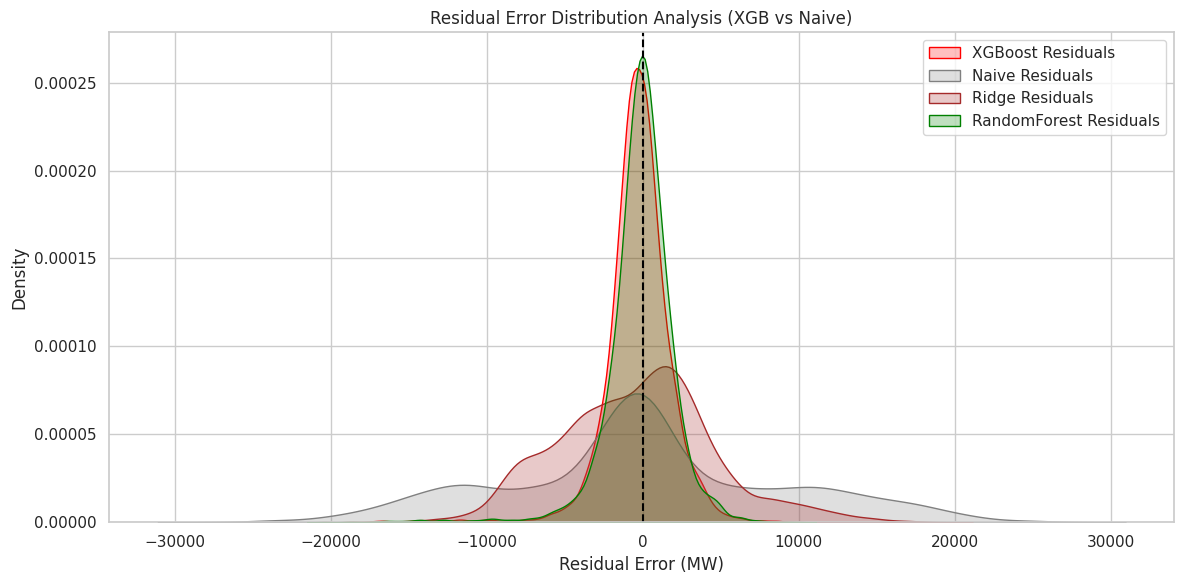

In [24]:
# Generating precise residual distributions seamlessly against core error deviations inherently
residuals_naive = y_test - y_pred_naive
residuals_ridge = y_test - y_pred_ridge
residuals_rf = y_test - y_pred_rf
residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(12, 6))
sns.kdeplot(residuals_xgb, label="XGBoost Residuals", shade=True, color="red")
sns.kdeplot(residuals_naive, label="Naive Residuals", shade=True, color="gray")
sns.kdeplot(residuals_ridge, label="Ridge Residuals", shade=True, color="brown")
sns.kdeplot(residuals_rf, label="RandomForest Residuals", shade=True, color="green")
plt.title("Residual Error Distribution Analysis (XGB vs Naive)")
plt.xlabel("Residual Error (MW)")
plt.ylabel("Density")
plt.axvline(0, color='black', linestyle="--")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(paths['figures'], "residuals_plot.png"))
plt.show()


/tmp/ipykernel_390/2256276799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")


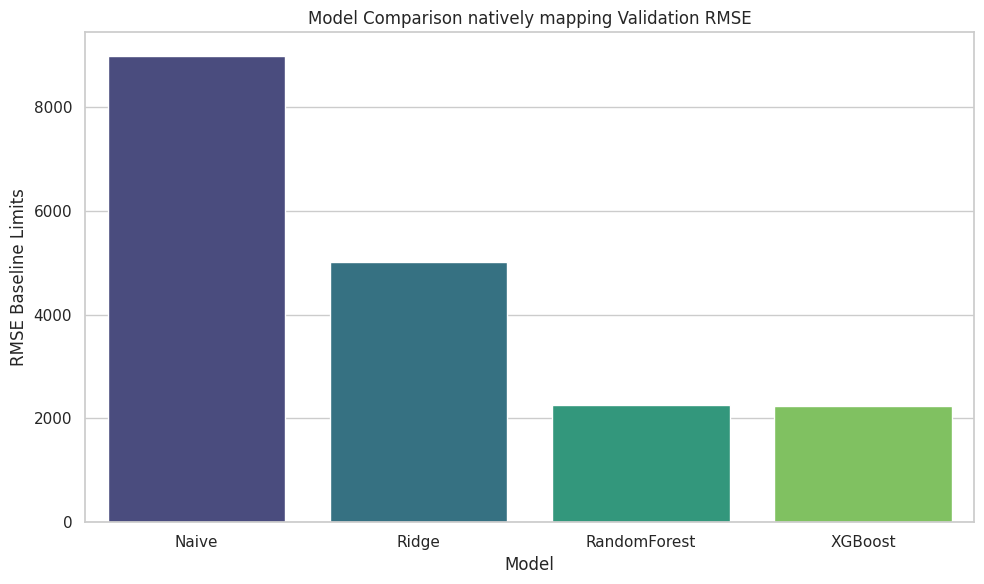

In [25]:
# Bar charts explicitly comparing distinct validation outcomes structurally evaluating precise RMSE limits structurally
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="viridis")
plt.title("Model Comparison natively mapping Validation RMSE")
plt.ylabel("RMSE Baseline Limits")
plt.tight_layout()
plt.savefig(os.path.join(paths['figures'], "model_comparison.png"))
plt.show()

## 8. Exporting Downstream Raw Test Log Records
Compile arrays strictly generating final aggregated boundaries implicitly aligned securely without altering test indices towards Google Drive artifacts intrinsically mapped backwards efficiently.

In [26]:
pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred_naive": y_pred_naive,
    "y_pred_ridge": y_pred_ridge,
    "y_pred_rf": y_pred_rf,
    "y_pred_xgb": y_pred_xgb
}, index=y_test.index)

# Index to native column if needed
pred_df = pred_df.reset_index()

pred_path = os.path.join(paths['figures'].replace("figures", ""), "predictions.parquet")
pred_df.to_parquet(pred_path, index=False)
print(f"Correctly persisted core validation arrays spanning strictly into structural arrays safely to {pred_path}")


Correctly persisted core validation arrays spanning strictly into structural arrays safely to /content/drive/MyDrive/energy-demand-forecast/results/predictions.parquet
